## Train Word2Vec Model (Advanced Feature Extraction)

In [1]:
import pandas as pd
import ast

papers_w2v = pd.read_csv('../data/papers_preprocessed.csv')
papers_w2v['lemmatized_tokens'] = papers_w2v['lemmatized_tokens'].apply(ast.literal_eval)

print(f"Loaded {len(papers_w2v)} papers")
print(f"Sample tokens: {papers_w2v['lemmatized_tokens'].iloc[0][:10]}")

Loaded 9607 papers
Sample tokens: ['bit_serial', 'neural', 'alan_murray', 'anthony', 'smith', 'zoe', 'butler', 'department_electrical', 'engineering_university', 'edinburgh']


In [2]:
from gensim.models import Word2Vec

sentences = papers_w2v['lemmatized_tokens'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,        
    workers=4,
    epochs=10,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)} words")
print(f"Embedding dimension: {w2v_model.vector_size}")

Vocabulary size: 164637 words
Embedding dimension: 100


In [3]:
print("\nMost similar to 'neural':")
print(w2v_model.wv.most_similar('neural', topn=5))


Most similar to 'neural':
[('neural_network', 0.6664369106292725), ('iclr_srivastava', 0.6114094257354736), ('neu_ral', 0.6061340570449829), ('depthwidth_tradeoff', 0.605005145072937), ('deep_convolutional', 0.599663496017456)]


In [4]:
import os
os.makedirs('../models', exist_ok=True)
w2v_model.save('../models/word2vec_nips.model')
print("Model saved.")

Model saved.


## Semantic Keyword Extraction via Vector Similarity

In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def get_doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return None
    return np.mean(vectors, axis=0)


def get_w2v_keywords(tokens, model, top_n=5):
    valid_tokens = [t for t in tokens if t in model.wv]
    if not valid_tokens:
        return []

    doc_vector = get_doc_vector(valid_tokens, model)
    if doc_vector is None:
        return []

    unique_tokens = list(set(valid_tokens))
    word_vectors = np.array([model.wv[t] for t in unique_tokens])

    similarities = cosine_similarity(doc_vector.reshape(1, -1), word_vectors)[0]

    scored = sorted(zip(unique_tokens, similarities), key=lambda x: x[1], reverse=True)
    return [word for word, score in scored[:top_n]]

In [ ]:
print("Extracting Word2Vec keywords...")

papers_w2v['w2v_keywords'] = papers_w2v['lemmatized_tokens'].apply(
    lambda tokens: get_w2v_keywords(tokens, w2v_model, top_n=5)
)

print("Done.\n")
for i in range(5):
    print(f"Paper {i}: {papers_w2v['lemmatized_tokens'].iloc[i]}")

In [7]:
test_words = ['neural', 'optimization', 'classification', 'gradient']

for word in test_words:
    if word in w2v_model.wv:
        print(f"\nMost similar to '{word}':")
        for similar_word, score in w2v_model.wv.most_similar(word, topn=8):
            print(f"  {similar_word}: {score:.4f}")


Most similar to 'neural':
  neural_network: 0.6664
  iclr_srivastava: 0.6114
  neu_ral: 0.6061
  depthwidth_tradeoff: 0.6050
  deep_convolutional: 0.5997
  soudry_elyaniv: 0.5986
  chine_translation: 0.5977
  recurrent_hessianfree: 0.5970

Most similar to 'optimization':
  opti_mization: 0.8560
  optimiza_tion: 0.8448
  timization: 0.8059
  optimiza: 0.7194
  nonconvex_optimization: 0.7191
  sequential_modelbased: 0.6988
  expensivetoevaluate_function: 0.6889
  mockus: 0.6853

Most similar to 'classification':
  clas_sification: 0.8021
  classi_fication: 0.7748
  classifier: 0.7721
  classifica_tion: 0.7657
  classi_cation: 0.7649
  classifi_cation: 0.7477
  binary_classification: 0.6978
  clas_siﬁcation: 0.6823

Most similar to 'gradient':
  gradi_ent: 0.7764
  gra_dient: 0.7497
  gra_dients: 0.7249
  pgcn: 0.6726
  gradi_ents: 0.6590
  θlθ: 0.6501
  pathw_derivative: 0.6475
  prox_oracle: 0.6427


In [8]:
for i in [0, 5, 10, 20, 50]:
    paper_title = papers_w2v['title'].iloc[i] if 'title' in papers_w2v.columns else f"Paper {i}"
    keywords = papers_w2v['w2v_keywords'].iloc[i]
    print(f"\nPaper {i}: {paper_title}")
    print(f"Keywords: {keywords}")


Paper 0: Bit-Serial Neural Networks
Keywords: ['noise_immunity', 'receiv_ing', 'silicon_wafer', 'satura_tion', 'aspire']

Paper 5: A Neural-Network Solution to the Concentrator Assignment Problem
Keywords: ['tij_tji', 'concentrator_assignment', 'jected', 'correspond', 'concentra']

Paper 10: Optimal Neural Spike Classification
Keywords: ['falsely_detect', 'singlespike', 'rather', 'rely_entirely', 'spatially_adjacent']

Paper 20: A Computer Simulation of Cerebral Neocortex: Computational Capabilities of Nonlinear Neural Networks
Keywords: ['confines', 'impressed', 'finegrain_connectivity', 'nonoscillatory', 'change_finegrain']

Paper 50: Correlational Strength and Computational Algebra of Synaptic Connections Between Neurons
Keywords: ['broadening', 'disynaptic_link', 'correlational_effect', 'monosynaptically', 'abovechance']


C:\Users\Reem\AppData\Local\Temp\ipykernel_14520\4159230544.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')


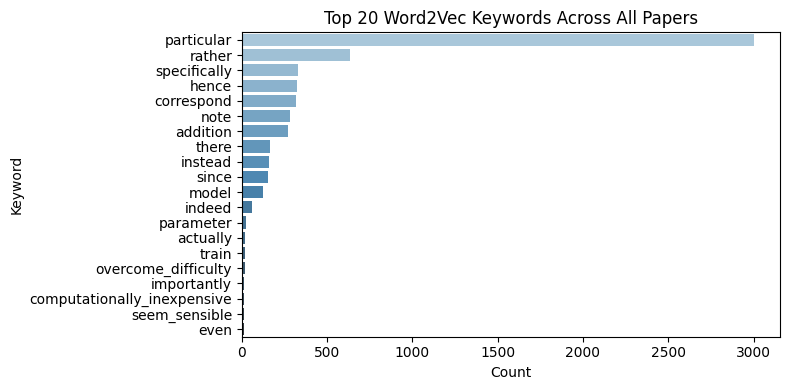

In [9]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

all_w2v_keywords = [kw for kws in papers_w2v['w2v_keywords'] for kw in kws]
top20 = pd.DataFrame(
    Counter(all_w2v_keywords).most_common(20),
    columns=['Keyword', 'Count']
)

sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')
plt.title('Top 20 Word2Vec Keywords Across All Papers')
plt.tight_layout()
plt.show()

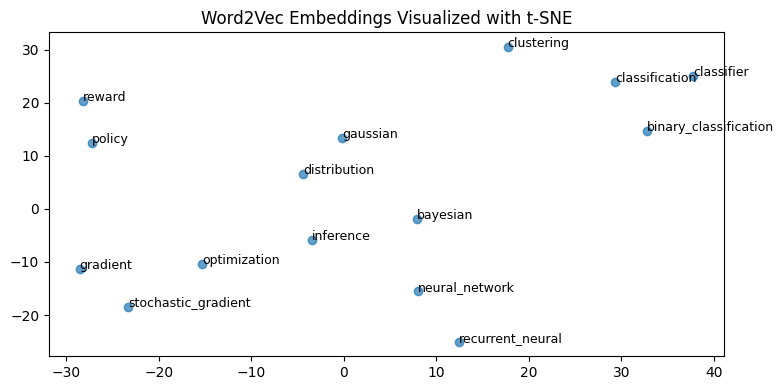

In [10]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

focus_words = [
    'neural_network', 'deep_feedforward', 'recurrent_neural',
    'gradient', 'stochastic_gradient', 'optimization',
    'classification', 'classifier', 'binary_classification',
    'bayesian', 'probabilistic', 'inference',
    'reinforcement', 'policy', 'reward',
    'clustering', 'gaussian', 'distribution'
]

focus_words = [w for w in focus_words if w in w2v_model.wv]

vectors = np.array([w2v_model.wv[w] for w in focus_words])

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 4))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)
for i, word in enumerate(focus_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title('Word2Vec Embeddings Visualized with t-SNE')
plt.tight_layout()
plt.show()

In [11]:
import json

os.makedirs('../results', exist_ok=True)

with open('../results/w2v_results.json', 'w') as f:
    json.dump(papers_w2v['w2v_keywords'].tolist(), f)

print("Saved to ../results/w2v_results.json")

Saved to ../results/w2v_results.json
